# Peak Cluster Feedstock De-Risking — Monte Carlo

Companion notebook to `Peak_Cluster_Feedstock_Derisking_Model.xlsx`. The Excel workbook is the
deterministic, point-estimate calculator (edit the blue cells, everything recalculates) — good
for walking a quarry engineering lead through a single scenario. This notebook is for the
*probabilistic* question: given real uncertainty in five inputs, how confident can we be that
Oxy-Fuel + Waste Heat Recovery + BESS beats baseline amine capture?

**Same formula chain as the spreadsheet's Baseline / Optimized / Comparison tabs** — nothing new
is being modelled here, just resampled many times over plausible input ranges.

Edit the distributions in the "Uncertain inputs" cell and re-run everything below (`Kernel → Restart & Run All`).

---
**Updated for Hope Cement Works (Breedon, Derbyshire)** — one of the four named Peak Cluster
sites, UK's largest cement plant (~16% of UK cement output). Real figures below replace the
generic 50MWth/300,000t template:

| Parameter | Old (generic) | New (Hope) | Source |
|---|---|---|---|
| Annual CO2 target | 300,000 t/yr | **1,200,000 t/yr** | Hope Valley Climate Action — cites Hope as "by far the largest emitter of greenhouse gases in the Hope Valley" |
| Kiln thermal rating | 50 MWth | **~140 MWth** | Calculated: 1.5Mt cement/yr x ~0.85 clinker ratio x 3.2 GJ/t (modern precalciner benchmark) / 8,000 op-hrs. **Not a confirmed nameplate figure** — no public source gives kiln MWth directly. |
| Baseline CO2% | 18% (generic cement) | **20%**, MC range 18-22% | Sourcing-table proxy for cement kilns specifically (lime kilns run richer, 25-35%, but Hope is cement-only) |
| Electricity tariff | £60-180/MWh (wide) | **£85-140/MWh** | DESNZ/Ofgem-informed range for large industrial users — narrower than the generic bound |

Still unresolved (no public source found): the O2 demand ratio and oxy-fuel retrofit capex remain
the two LOW/MEDIUM confidence placeholders — these need either a vendor mass-balance study or the
actual EA permit's stack flow data (the permit variation documents exist publicly at
consult.environment-agency.gov.uk but weren't pulled in this pass).
---

## 1. Fixed assumptions

Same defaults as the Assumptions tab. Change these here if your site differs from the generic 50 MWth / 300,000 t/yr template.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # change or remove the seed to get a fresh draw each run
N = 10_000

# --- Fixed assumptions (Assumptions tab defaults) ---
VOL = 1_200_000          # t CO2/yr target (Hope Cement Works — Hope Valley Climate Action)
CO2_REF = 0.20            # reference CO2% used to scale amine reboiler duty
AMINE_THERMAL = 900.0     # kWh-th/t CO2 at reference CO2%
THERMAL_COST = 35.0       # £/MWh-th (steam)
AMINE_ELEC = 40.0         # kWh/t CO2 (amine aux load)
COMPR = 105.0             # kWh/t CO2 (compression to pipeline spec, both pathways)
AMINE_CAPEX_TPA = 320.0   # £/tpa capacity
AMINE_OPEX_T = 8.0        # £/t CO2 (non-energy)
ASU_SPEC = 300.0          # kWh/t O2 (ASU specific energy)
ASU_CAPEX_TPA = 160.0     # £/tpa O2 capacity
PURIF = 30.0              # kWh/t CO2 (pipeline-spec purification/drying)
OXY_OPEX_T = 5.0          # £/t CO2 (non-energy)
KILN_MW = 140.0           # MWth kiln thermal rating (calculated estimate, see site note above — not a confirmed nameplate figure)
WHR_FRAC = 0.35           # % of kiln heat recoverable
ORC_EFF = 0.18            # ORC thermal-to-electric efficiency
ORC_CAPEX_MWE = 2_000_000.0  # £/MWe installed
HOURS = 8000.0            # kiln operating hours/yr
BESS_CAPEX_KWH = 280.0    # £/kWh installed
BESS_MW = 10.0
BESS_HRS = 4.0
DISC = 0.08                # discount rate
LIFE = 20                  # years

CRF = (DISC * (1 + DISC) ** LIFE) / ((1 + DISC) ** LIFE - 1)
print(f"Capital recovery factor: {CRF:.4f}")


Capital recovery factor: 0.1019


## 2. Uncertain inputs — the 5 sampled variables

Distributions as specified in the pitch-strategy feedback:

| Variable | Distribution | Range/params |
|---|---|---|
| Baseline flue gas CO2% | Triangular | min 18%, mode 20%, max 22% (Hope, cement-only) |
| O2 demand ratio | Normal | mean 0.30, SD 0.04, clipped to [0.20, 0.40] |
| Oxy-fuel retrofit capex | Uniform | £30/tpa – £80/tpa |
| Avoided grid-reinforcement credit | Uniform | £0 – £5,000,000 |
| Grid electricity tariff | Normal | mean £105/MWh, SD £15, clipped to [£85, £140] |

Independent sampling is assumed — a real simplification (e.g. high tariffs and tight grid capacity
plausibly correlate). Worth revisiting if this goes into a board-level paper.

In [2]:
co2_pct = rng.triangular(0.18, 0.20, 0.22, N)   # tightened to cement-kiln-specific sourcing-table range
o2_ratio = np.clip(rng.normal(0.30, 0.04, N), 0.20, 0.40)
retrofit_capex_tpa = rng.uniform(30, 80, N)
grid_offset = rng.uniform(0, 5_000_000, N)
tariff = np.clip(rng.normal(105, 15, N), 85, 140)   # narrowed to DESNZ/Ofgem-informed large-industrial range

print("Sampled ranges (should match the distributions above):")
for name, arr in [("CO2%", co2_pct), ("O2 ratio", o2_ratio), ("Retrofit capex £/tpa", retrofit_capex_tpa),
                   ("Grid offset £", grid_offset), ("Tariff £/MWh", tariff)]:
    print(f"  {name:22s} min={arr.min():.3f}  mean={arr.mean():.3f}  max={arr.max():.3f}")


Sampled ranges (should match the distributions above):
  CO2%                   min=0.181  mean=0.200  max=0.220
  O2 ratio               min=0.200  mean=0.301  max=0.400
  Retrofit capex £/tpa   min=30.002  mean=55.126  max=79.999
  Grid offset £          min=137.324  mean=2503959.255  max=4999545.793
  Tariff £/MWh           min=85.000  mean=105.281  max=140.000


## 3. Baseline — amine capture

Exact formula chain from the `Baseline` tab.

In [3]:
reboiler_kwh_t = AMINE_THERMAL * (CO2_REF / co2_pct)
thermal_cost_t = reboiler_kwh_t * THERMAL_COST / 1000
elec_cost_t = (AMINE_ELEC + COMPR) * tariff / 1000
base_opex_t = thermal_cost_t + elec_cost_t + AMINE_OPEX_T

base_capex = AMINE_CAPEX_TPA * VOL
base_lev_capex_t = (base_capex * CRF) / VOL   # constant — doesn't depend on the sampled variables
base_allin = base_opex_t + base_lev_capex_t

print(f"Baseline all-in cost: mean £{base_allin.mean():.2f}/t  (levelized capex component is fixed at £{base_lev_capex_t:.2f}/t)")


Baseline all-in cost: mean £87.42/t  (levelized capex component is fixed at £32.59/t)


## 4. Optimized — oxy-fuel + ASU + waste heat recovery + BESS

Exact formula chain from the `Optimized` tab.

In [4]:
o2_t = o2_ratio * VOL
total_kwh_t = o2_ratio * ASU_SPEC + PURIF + COMPR
total_mwh = total_kwh_t * VOL / 1000

heat_mw = KILN_MW * WHR_FRAC
orc_mw = heat_mw * ORC_EFF
whr_mwh = orc_mw * HOURS      # constant — WHR generation doesn't depend on the sampled variables

netgrid_mwh = np.maximum(0, total_mwh - whr_mwh)
opt_opex_t = (netgrid_mwh * tariff + OXY_OPEX_T * VOL) / VOL

asu_capex = ASU_CAPEX_TPA * o2_t
retrofit_capex = retrofit_capex_tpa * VOL
orc_capex = orc_mw * ORC_CAPEX_MWE                      # constant
bess_capex = BESS_MW * BESS_HRS * 1000 * BESS_CAPEX_KWH  # constant
capex_gross = asu_capex + retrofit_capex + orc_capex + bess_capex
capex_net = capex_gross - grid_offset

opt_lev_capex_t = (capex_net * CRF) / VOL
opt_allin = opt_opex_t + opt_lev_capex_t

print(f"Optimized all-in cost: mean £{opt_allin.mean():.2f}/t")
print(f"WHR share of optimized electrical load (at defaults): {whr_mwh / total_mwh.mean() * 100:.1f}% (varies with O2 ratio draw)")


Optimized all-in cost: mean £35.26/t
WHR share of optimized electrical load (at defaults): 26.1% (varies with O2 ratio draw)


## 5. Savings distribution and percentiles

In [5]:
savings = base_allin - opt_allin

p10, p50, p90 = np.percentile(savings, [10, 50, 90])
win_rate = (savings > 0).mean()

print(f"P10 (worst 10% case)  : £{p10:.2f} / t CO2")
print(f"P50 (median)          : £{p50:.2f} / t CO2")
print(f"P90 (best case)       : £{p90:.2f} / t CO2")
print(f"Mean                  : £{savings.mean():.2f} / t   SD: £{savings.std():.2f} / t")
print(f"Min / Max observed    : £{savings.min():.2f} / £{savings.max():.2f}")
print(f"Win rate (optimized cheaper): {win_rate*100:.2f}%  ({(savings>0).sum():,} / {N:,} draws)")


P10 (worst 10% case)  : £48.60 / t CO2
P50 (median)          : £52.13 / t CO2
P90 (best case)       : £55.77 / t CO2
Mean                  : £52.16 / t   SD: £2.76 / t
Min / Max observed    : £41.58 / £61.32
Win rate (optimized cheaper): 100.00%  (10,000 / 10,000 draws)


## 6. Sanity check against the pasted pitch claim

The £46.67/£53.95/£62.00 figures below are what the *generic 300,000t/50MWth* template produced with the wider distributions — kept here only as a before/after reference now that the model runs on Hope's real ~1.2Mt/140MWth scale with tightened CO2%/tariff ranges. Don't quote the £46.67-£62.00 range for Hope specifically; use whatever this notebook prints on the current run.

In [6]:
claimed = {"P10": 46.67, "P50": 53.95, "P90": 62.00, "win_rate": 1.00}
computed = {"P10": p10, "P50": p50, "P90": p90, "win_rate": win_rate}

print(f"{'Statistic':10s} {'Computed (this run)':>20s} {'Pasted claim':>15s} {'Delta':>10s}")
for k in claimed:
    c, cl = computed[k], claimed[k]
    print(f"{k:10s} {c:20.2f} {cl:15.2f} {c-cl:10.2f}")


Statistic   Computed (this run)    Pasted claim      Delta
P10                       48.60           46.67       1.93
P50                       52.13           53.95      -1.82
P90                       55.77           62.00      -6.23
win_rate                   1.00            1.00       0.00


## 7. Distribution plot

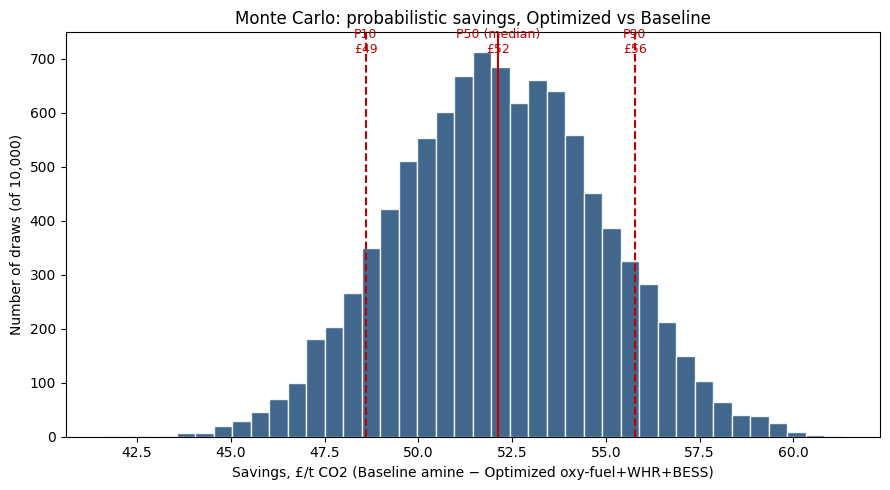

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(savings, bins=40, color="#1F4E78", edgecolor="white", alpha=0.85)
for val, label, style in [(p10, "P10", "--"), (p50, "P50 (median)", "-"), (p90, "P90", "--")]:
    ax.axvline(val, color="#C00000", linestyle=style, linewidth=1.5)
    ax.text(val, ax.get_ylim()[1]*0.95, f"{label}\n£{val:.0f}", ha="center", fontsize=9, color="#C00000")
ax.set_xlabel("Savings, £/t CO2 (Baseline amine − Optimized oxy-fuel+WHR+BESS)")
ax.set_ylabel("Number of draws (of 10,000)")
ax.set_title("Monte Carlo: probabilistic savings, Optimized vs Baseline")
plt.tight_layout()
plt.savefig("monte_carlo_distribution.png", dpi=150)
plt.show()


## 8. What actually drives the range (for the pitch "hook" step)

Quick single-variable sensitivity: correlate each sampled input against the resulting savings to
see which uncertainty matters most. This is the evidence behind "we can narrow this range with
your specific kiln data" — show whichever variable has the highest |correlation|.

In [8]:
import pandas as pd

df = pd.DataFrame({
    "co2_pct": co2_pct, "o2_ratio": o2_ratio, "retrofit_capex_tpa": retrofit_capex_tpa,
    "grid_offset": grid_offset, "tariff": tariff, "savings": savings,
})
corr = df.corr()["savings"].drop("savings").sort_values(key=lambda s: -s.abs())
print("Correlation with £/t savings (sign shows direction, magnitude shows influence):")
print(corr.round(3))


Correlation with £/t savings (sign shows direction, magnitude shows influence):
o2_ratio             -0.700
retrofit_capex_tpa   -0.545
co2_pct              -0.461
tariff               -0.087
grid_offset           0.037
Name: savings, dtype: float64


## 9. Next steps

- Tighten the O2 demand ratio and retrofit capex ranges first — Section 8 should show these are
  the dominant drivers, and they're also the two flagged LOW/MEDIUM confidence on the Assumptions
  tab (no public commercial benchmark for oxy-fuel kiln retrofit capex yet).
- Swap in real site data as you get it under NDA (stack CO2%, O2 mass balance, actual DNO quote,
  actual tariff) — replace the relevant `rng.*` line with a fixed value or a tighter distribution.
- If you want site-specific correlation (e.g. tariff and grid-offset moving together), add a
  copula or just correlate the draws before computing — flag if useful and I'll build it in.
- To rebuild the spreadsheet version of this Monte Carlo tab once the environment issue with this
  session's LibreOffice service is resolved, this notebook has everything needed — same formulas,
  same distributions.